# Structure Notebook


0. Research Question

1. Data Preparation and Initial Overview

    1.1 Load Data
    1.2 Codebook Review
    1.3 Variable Selection
    1.4 Data Quality Checks

2. Exploratory Analysis and Descriptive Visualization

    2.1 Participant Characteristics
    2.2 Outcome Distributions
    2.3 Pre/Post Visualizations

3. Statistical Analysis

    3.1 Primary Outcome
           MHL Total

    3.2 Secondary Outcomes
           MHL Subscales

    3.3 Exploratory Outcomes
           Self-Efficacy
           Stigma
           Affect
           Flourishing

4. Discussion and Conclusions

# 0- Research question

Objective:
To evaluate whether a ChatGPT-supported mental health literacy intervention was associated with pre/post improvements in mental health literacy among participants, while descriptively exploring changes in related outcomes such as self-efficacy, help-seeking attitudes, stigma, affect, and flourishing.

Primary outcome
•	MHL_Total 

Secondary MHL outcomes
•	MHL_KMHP 
•	MHL_EBS 
•	MHL_FASHSB 
•	MHL_SHS 

Exploratory psychological outcomes
•	MHSES 
•	MHSAS 
•	STIG 
•	SPANE_P 
•	SPANE_N 
•	SPANE_B 
•	FLOUSC 

Acceptability outcomes
•	GPT_Rating 
•	Prompts_Rating 
•	Intervention_Rating 
•	MHL_Rating 
•	GPT_MHL 
•	GPT_Flaw 


# 1- Data Preparation and Initial Overview

In [2]:
%load_ext autoreload
%autoreload 2

from mh.paths import DATA_DIR, RAW_DIR, PROC_DIR, PROJECT_ROOT
from mh import read_csv_from_raw, write_csv_to_processed,data_overview

In [3]:
# -----filenames -----
DATA_FILE     = "mental_health_data.csv"
CODEBOOK_FILE = "mental_health_codebook.csv"   

# ----- load -----
data = read_csv_from_raw(DATA_FILE)
codebook = read_csv_from_raw(CODEBOOK_FILE) if CODEBOOK_FILE else None

In [3]:
# --- Quick structural check: shape, top 3 rows, dtypes, numerica summary, missingness, unique counts, duplicates, categorical preview ---
overview = data_overview(data, top=15)

Shape: 51 rows × 34 columns

Top 3 rows (quick peek):


,Age,Gender,Educational.Qualification,GPT_Use,pre.MHL_KMHP,pre.MHL_EBS,pre.MHL_FASHSB,pre.MHL_SHS,pre.MHL_Total,pre.MHSAS,...,post.SPANE_P,post.SPANE_N,post.SPANE_B,post.FLOUSC,GPT_Rating,Prompts_Rating,Intervention_Rating,MHL_Rating,GPT_MHL,GPT_Flaw
0,19,Female,Bcom,Occasionally (once or twice),28,12,13,19,72,4.777778,...,16,21,-5,32,Good,Excellent,Good,Yes,Maybe,No
1,20,Male,Bcom computer application,Occasionally (once or twice),29,11,14,19,73,6.111111,...,15,20,-5,30,Excellent,Excellent,Excellent,Yes,Yes,No
2,19,Female,Pursuing a Bachelor's degree (BA/ BSc/ BTech),Always (daily),25,12,13,17,67,6.444444,...,21,16,5,40,Good,Good,Excellent,Yes,Yes,No



Dtypes (sorted by column name):


Age                            int64
Educational.Qualification     object
GPT_Flaw                      object
GPT_MHL                       object
GPT_Rating                    object
GPT_Use                       object
Gender                        object
Intervention_Rating           object
MHL_Rating                    object
Prompts_Rating                object
post.FLOUSC                    int64
post.MHL_EBS                   int64
post.MHL_FASHSB                int64
post.MHL_KMHP                  int64
post.MHL_SHS                   int64
post.MHL_Total                 int64
post.MHSAS                   float64
post.MHSES                     int64
post.SPANE_B                   int64
post.SPANE_N                   int64
post.SPANE_P                   int64
post.STIG                      int64
pre.FLOUSC                     int64
pre.MHL_EBS                    int64
pre.MHL_FASHSB                 int64
pre.MHL_KMHP                   int64
pre.MHL_SHS                    int64
p


Numeric summary (describe):


...

Intervention_Rating
Good         26
Excellent    24
Fair          1
Name: count, dtype: int64

  • MHL_Rating


MHL_Rating
Yes      43
Maybe     8
Name: count, dtype: int64

  • GPT_MHL


GPT_MHL
Yes      37
Maybe    13
No        1
Name: count, dtype: int64

Codebook normalization

The original codebook uses raw variable names that are not convenient for analysis.  
To improve readability and reproducibility, variable names were converted to snake_case and saved as a normalized codebook.

In [4]:
display(codebook.head(10))

,Age,Age of the Particiapant,in numbers
0,Gender,Gender of the Participant,Male/ Female/ Other
1,Educational.Qualification,Educational qualification of the Participant,Pursuing/ completed a Bachelor's/ Master's degree
2,GPT_Use,Have you used ChatGPT?,Occasionally/ Always/ Never
3,pre.MHL_KMHP,Pre-test - Mental Health Literacy - Knowledge ...,Mental Health Literacy questionnaire-Short Ver...
4,pre.MHL_EBS,Pre-test - Mental Health Literacy - Erroneous ...,Mental Health Literacy questionnaire-Short Ver...
5,pre.MHL_FASHSB,Pre-test - Mental Health Literacy - First aid ...,Mental Health Literacy questionnaire-Short Ver...
6,pre.MHL_SHS,Pre-test - Mental Health Literacy - Self-help ...,Mental Health Literacy questionnaire-Short Ver...
7,pre.MHL_Total,Pre-test - Mental Health Literacy - Total,Mental Health Literacy questionnaire-Short Ver...
8,pre.MHSAS,Pre-test - Mental Help seeking Attitude,Mental Help Seeking Attitudes Scale (Hammer et...
9,pre.STIG,Pre-test - Stigma,"Stigma-9 Questionnaire (Gierk et al., 2018)"


In [5]:
# --- 1. Read the codebook with no header ---
cb_raw = read_csv_from_raw(CODEBOOK_FILE, header=None)

# --- 2. Assign meaningful column names ---
cb_raw.columns = ["variable", "description", "notes"]

# --- 3. Hygiene  ---
cb_raw["variable"] = cb_raw["variable"].astype(str).str.strip()
cb_raw["description"] = cb_raw["description"].astype(str).str.strip()
cb_raw["notes"] = cb_raw["notes"].astype(str).str.strip()

# Display
display(cb_raw.head(10))

,variable,description,notes
0,Age,Age of the Particiapant,in numbers
1,Gender,Gender of the Participant,Male/ Female/ Other
2,Educational.Qualification,Educational qualification of the Participant,Pursuing/ completed a Bachelor's/ Master's degree
3,GPT_Use,Have you used ChatGPT?,Occasionally/ Always/ Never
4,pre.MHL_KMHP,Pre-test - Mental Health Literacy - Knowledge ...,Mental Health Literacy questionnaire-Short Ver...
5,pre.MHL_EBS,Pre-test - Mental Health Literacy - Erroneous ...,Mental Health Literacy questionnaire-Short Ver...
6,pre.MHL_FASHSB,Pre-test - Mental Health Literacy - First aid ...,Mental Health Literacy questionnaire-Short Ver...
7,pre.MHL_SHS,Pre-test - Mental Health Literacy - Self-help ...,Mental Health Literacy questionnaire-Short Ver...
8,pre.MHL_Total,Pre-test - Mental Health Literacy - Total,Mental Health Literacy questionnaire-Short Ver...
9,pre.MHSAS,Pre-test - Mental Help seeking Attitude,Mental Help Seeking Attitudes Scale (Hammer et...


In [6]:
# --- Normalize codebook ---

import re
from pathlib import Path

# Add a normalized variable name in snake_case
def to_snake(name: str) -> str:
    """
    Convert variable names like 'pre.MHL_Total' → 'pre_mhl_total'
    Handles dots, spaces, and mixed cases.
    """
    name = str(name)
    name = re.sub(r'[^0-9a-zA-Z]+', '_', name)   # replace punctuation with _
    name = re.sub(r'([a-z])([A-Z])', r'\1_\2', name)  # handle camel case
    return name.lower().strip('_')

cb_raw["variable_new"] = cb_raw["variable"].apply(to_snake)

# Quick visual check
display(cb_raw.head(10))

# Save normalized version for future reference
processed_path = DATA_DIR / "processed" / "codebook_normalized.csv"
Path(processed_path).parent.mkdir(parents=True, exist_ok=True)
cb_raw.to_csv(processed_path, index=False)

#print(f"Normalized codebook saved to: {processed_path}")

# Preview of mappings (sanity check)
print("\nExample mappings:")
for i in range(8):
    print(f"{cb_raw.loc[i,'variable']:30s} → {cb_raw.loc[i,'variable_new']}")


,variable,description,notes,variable_new
0,Age,Age of the Particiapant,in numbers,age
1,Gender,Gender of the Participant,Male/ Female/ Other,gender
2,Educational.Qualification,Educational qualification of the Participant,Pursuing/ completed a Bachelor's/ Master's degree,educational_qualification
3,GPT_Use,Have you used ChatGPT?,Occasionally/ Always/ Never,gpt_use
4,pre.MHL_KMHP,Pre-test - Mental Health Literacy - Knowledge ...,Mental Health Literacy questionnaire-Short Ver...,pre_mhl_kmhp
5,pre.MHL_EBS,Pre-test - Mental Health Literacy - Erroneous ...,Mental Health Literacy questionnaire-Short Ver...,pre_mhl_ebs
6,pre.MHL_FASHSB,Pre-test - Mental Health Literacy - First aid ...,Mental Health Literacy questionnaire-Short Ver...,pre_mhl_fashsb
7,pre.MHL_SHS,Pre-test - Mental Health Literacy - Self-help ...,Mental Health Literacy questionnaire-Short Ver...,pre_mhl_shs
8,pre.MHL_Total,Pre-test - Mental Health Literacy - Total,Mental Health Literacy questionnaire-Short Ver...,pre_mhl_total
9,pre.MHSAS,Pre-test - Mental Help seeking Attitude,Mental Help Seeking Attitudes Scale (Hammer et...,pre_mhsas



Example mappings:
Age                            → age
Gender                         → gender
Educational.Qualification      → educational_qualification
GPT_Use                        → gpt_use
pre.MHL_KMHP                   → pre_mhl_kmhp
pre.MHL_EBS                    → pre_mhl_ebs
pre.MHL_FASHSB                 → pre_mhl_fashsb
pre.MHL_SHS                    → pre_mhl_shs


Rename the data columns according to the normalized codebook and build some minimal clean labels

In [8]:
# --- Load normalized codebook ---
import pandas as pd

cb = pd.read_csv(PROC_DIR / "codebook_normalized.csv")

# Build maps
rename_map = dict(zip(cb["variable"], cb["variable_new"]))     # raw → snake_case
labels     = dict(zip(cb["variable_new"], cb["description"]))  # snake_case → human label

# --- Apply renaming to dataset `data` ---
data_renamed = data.rename(columns=rename_map).copy()

# Optional: small manual niceties 
manual = {
    "educational_qualification": "education"
}
data_renamed.rename(columns=manual, inplace=True)

# Update labels 
if "educational_qualification" in labels:
    labels["education"] = labels.pop("educational_qualification")

# --- Sanity checks ---
old_cols = set(data.columns)
new_cols = set(data_renamed.columns)
print("Renamed columns:", len(old_cols & set(rename_map.keys())))
print("Final columns:", len(new_cols))

# Any columns that didn't get mapped? (fine if some are demographics already OK)
unmapped = [c for c in data.columns if c not in rename_map and c not in manual]
print("Unmapped (expected small list, often demographics):", unmapped)

# --- Save clean analysis-ready data ---
write_csv_to_processed(data_renamed, "clean.csv")
#print("Saved:", PROC_DIR / "clean.csv")


Renamed columns: 34
Final columns: 34
Unmapped (expected small list, often demographics): []


WindowsPath('C:/Users/alexa/OneDrive/AlexPerez/Dokumente/00_projectsds/mental_health_sep25/01_data/processed/clean.csv')

# 2- Exploratory Analysis and Descriptive Visualization

### Paired t-test assumptions

Because the study uses a pre/post design with the same participants measured twice, paired t-tests were selected for the main inferential analyses.

The key assumptions are:

1. Paired observations: each pre-test score corresponds to the same participant's post-test score.
2. Numeric outcome variables.
3. Independence between participants.
4. Approximately normal distribution of paired differences: Post − Pre.
5. No extreme influential outliers in the paired differences.

The first three assumptions are addressed by the study design and data structure. The last two are assessed visually using histograms and QQ plots of paired differences.

In [9]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Project paths (package)
from mh.paths import PROC_DIR, FIGURES_DIR

# Read directly:
data_path     = PROC_DIR / "clean.csv"
codebook_path = PROC_DIR / "codebook_normalized.csv"

data     = pd.read_csv(data_path)
codebook = pd.read_csv(codebook_path)

# Build labels dict (snake_case → human label). Fallback to column name if missing.
labels = dict(zip(codebook["variable_new"], codebook["description"]))
def L(col: str) -> str:
    return labels.get(col, col.replace("_", " ").title())


In [ ]:
# Consistent style
sns.set_theme(style="whitegrid", context="talk")  # big labels, clean grid

# Small helper to add percentage labels on bars
def add_bar_labels(ax, total_n: int):
    for p in ax.patches:
        count = int(p.get_height())
        if total_n > 0:
            pct = 100 * count / total_n
            ax.annotate(f"{count} ({pct:.1f}%)",
                        (p.get_x() + p.get_width()/2, p.get_height()),
                        ha="center", va="bottom", xytext=(0, 5),
                        textcoords="offset points", fontsize=11)

# Generic categorical plotter: sorted by frequency, percent labels, saved to disk
def plot_categorical(df: pd.DataFrame, col: str, fname: str,
                     order=None, note: str = "", horizontal=False):
    """
    Generic categorical plotter.
    horizontal=True → makes a horizontal bar chart (better for long labels).
    """
    series = df[col].astype("category")
    counts = series.value_counts(dropna=False)
    if order is None:
        order = counts.index.tolist()  # frequency order

    plt.figure(figsize=(9, 6))

    if horizontal:
        ax = sns.countplot(data=df, y=col, order=order)  # <— switched to y
        ax.set_xlabel("Count")
        ax.set_ylabel(L(col))
    else:
        ax = sns.countplot(data=df, x=col, order=order)
        ax.set_xlabel(L(col))
        ax.set_ylabel("Count")
        plt.setp(ax.get_xticklabels(), rotation=15, ha="right")

    ax.set_title(f"Distribution of {L(col)}")

    # Add count and percentage labels
    total_n = len(df)
    for p in ax.patches:
        count = int(p.get_width()) if horizontal else int(p.get_height())
        if total_n > 0:
            pct = 100 * count / total_n
            if horizontal:
                ax.annotate(f"{count} ({pct:.1f}%)",
                            (count, p.get_y() + p.get_height()/2),
                            ha="left", va="center",
                            xytext=(5, 0), textcoords="offset points", fontsize=11)
            else:
                ax.annotate(f"{count} ({pct:.1f}%)",
                            (p.get_x() + p.get_width()/2, p.get_height()),
                            ha="center", va="bottom",
                            xytext=(0, 5), textcoords="offset points", fontsize=11)

    # Optional note
    if note:
        ax.text(0.0, -0.22, note, transform=ax.transAxes,
                fontsize=11, va="top", ha="left")

    plt.tight_layout()
    out = FIGURES_DIR / fname
    out.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    #print("Saved figure →", out)

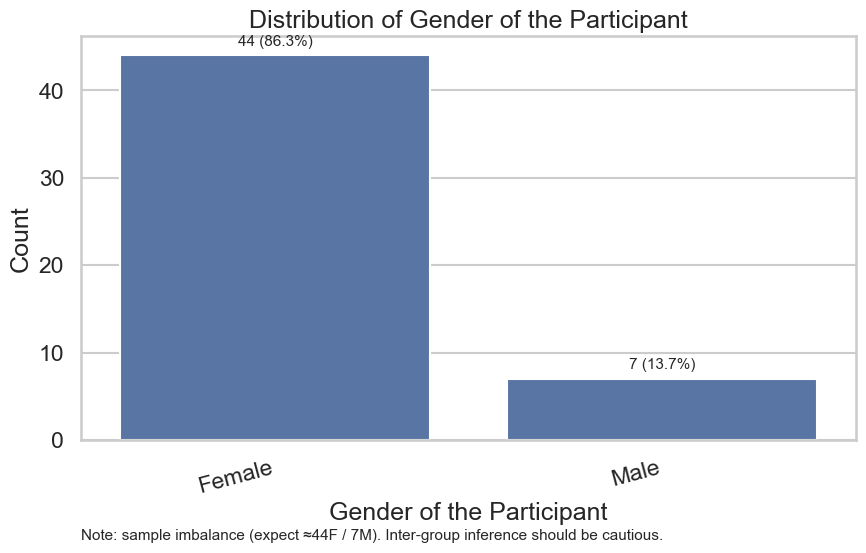

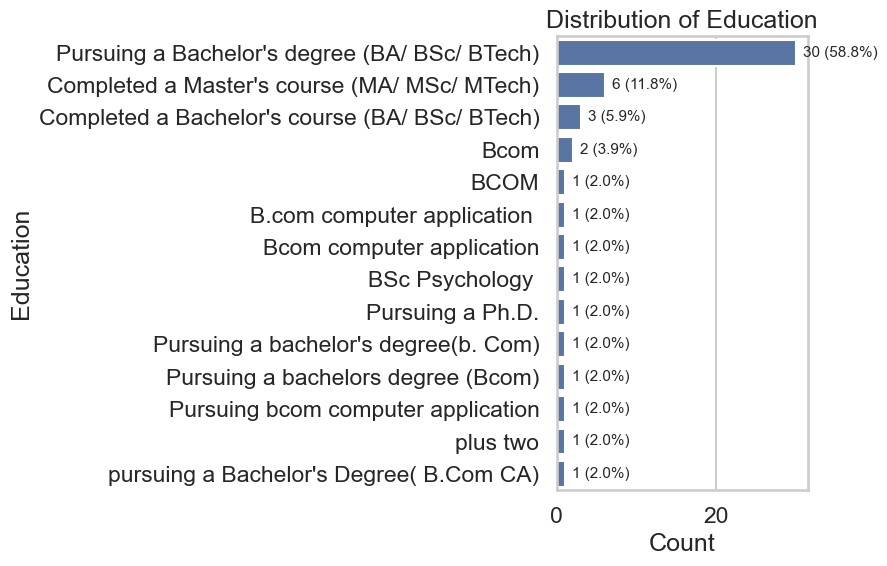

In [11]:
## Univariate Descriptives - Categorical

# 1) Gender (known imbalance)
plot_categorical(
    data, 
    col="gender", 
    fname="dist_gender.png",
    note="Note: sample imbalance (expect ≈44F / 7M). Inter-group inference should be cautious."
)

# 2) Education (rename you chose: 'education')
plot_categorical(
    data, 
    col="education", 
    fname="dist_education.png",
    horizontal=True
)

In [ ]:
## Univariate Descriptives - Numeric 

The following table provides a broad numeric overview of the dataset, including pre/post outcome variables. 
The main inferential focus is narrowed later through the predefined outcome hierarchy.

In [12]:
# Identify numeric cols (auto or manual)
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()
display(numeric_cols)

# Quick summary table
desc = data[numeric_cols].describe().T
desc['n_missing'] = data[numeric_cols].isna().sum()
display(desc)

['age',
 'pre_mhl_kmhp',
 'pre_mhl_ebs',
 'pre_mhl_fashsb',
 'pre_mhl_shs',
 'pre_mhl_total',
 'pre_mhsas',
 'pre_stig',
 'pre_mhses',
 'pre_spane_p',
 'pre_spane_n',
 'pre_spane_b',
 'pre_flousc',
 'post_mhl_kmhp',
 'post_mhl_ebs',
 'post_mhl_fashsb',
 'post_mhl_shs',
 'post_mhl_total',
 'post_mhsas',
 'post_stig',
 'post_mhses',
 'post_spane_p',
 'post_spane_n',
 'post_spane_b',
 'post_flousc']

,count,mean,std,min,25%,50%,75%,max,n_missing
age,51.0,19.823529,1.807826,18.000000,19.000000,19.000000,20.000000,25.0,0
pre_mhl_kmhp,51.0,24.137255,3.364637,18.000000,22.000000,24.000000,26.000000,30.0,0
pre_mhl_ebs,51.0,12.411765,1.675428,9.000000,12.000000,12.000000,13.500000,15.0,0
pre_mhl_fashsb,51.0,12.098039,1.910549,8.000000,11.000000,12.000000,13.000000,15.0,0
pre_mhl_shs,51.0,16.529412,1.724563,11.000000,15.000000,17.000000,17.500000,20.0,0
pre_mhl_total,51.0,65.176471,5.931967,53.000000,62.000000,65.000000,68.500000,77.0,0
pre_mhsas,51.0,5.808279,1.045408,3.555556,5.111111,6.111111,6.666667,7.0,0
pre_stig,51.0,16.725490,5.862008,0.000000,13.500000,17.000000,22.000000,27.0,0
pre_mhses,51.0,35.392157,10.579373,15.000000,27.500000,36.000000,41.000000,55.0,0
pre_spane_p,51.0,19.372549,3.918983,12.000000,17.000000,19.000000,22.500000,30.0,0


In [13]:
# Plot helper

def plot_numeric(df, col, bins=20):
    plt.figure(figsize=(8,5))
    ax = sns.histplot(df[col], bins=bins, kde=True)
    ax.set_title(f"Distribution of {L(col)}")
    ax.set_xlabel(L(col))
    plt.tight_layout()
    out = FIGURES_DIR / f"dist_{col}.png"
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    #print("Saved figure →", out)


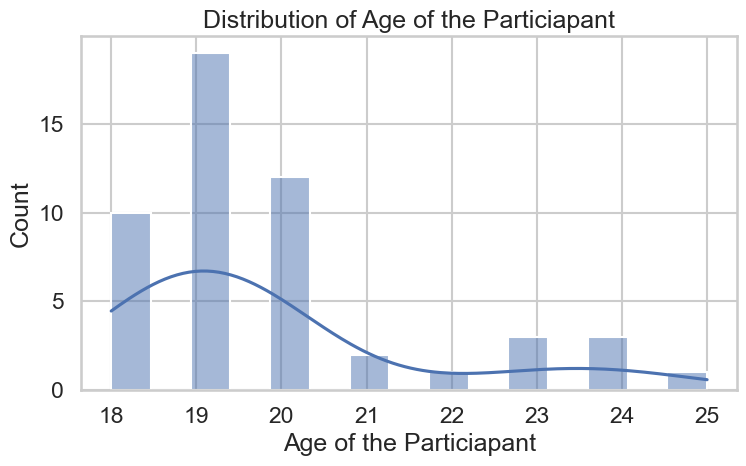

In [14]:
plot_numeric(data, "age", bins=15)

In [15]:
# ------------------------------------------------------------
# Pre/Post slope plots by outcome hierarchy
# ------------------------------------------------------------

# 1. Primary outcome: main efficacy endpoint
primary_pairs = [
    ("pre_mhl_total", "post_mhl_total"),
]

# 2. Secondary outcomes: MHL subscales
secondary_mhl_pairs = [
    ("pre_mhl_kmhp", "post_mhl_kmhp"),
    ("pre_mhl_ebs", "post_mhl_ebs"),
    ("pre_mhl_fashsb", "post_mhl_fashsb"),
    ("pre_mhl_shs", "post_mhl_shs"),
]

# 3. Exploratory psychological outcomes
exploratory_pairs = [
    ("pre_mhses", "post_mhses"),
    ("pre_mhsas", "post_mhsas"),
    ("pre_stig", "post_stig"),
    ("pre_spane_p", "post_spane_p"),
    ("pre_spane_n", "post_spane_n"),
    ("pre_spane_b", "post_spane_b"),
    ("pre_flousc", "post_flousc"),
]

In [16]:
def plot_prepost(df, pre, post, group_name=""):
    """
    Slope plot for a paired pre/post comparison.
    Shows individual participant change lines and group means ± SD.
    """

    paired = df[[pre, post]].dropna()

    fig, ax = plt.subplots(figsize=(8, 6))

    # Individual participant lines
    for _, row in paired.iterrows():
        ax.plot(
            [0, 1],
            [row[pre], row[post]],
            color="lightgray",
            alpha=0.5,
            linewidth=1
        )

    # Mean values
    mean_pre = paired[pre].mean()
    mean_post = paired[post].mean()

    ax.scatter(
        0,
        mean_pre,
        color="#1f77b4",
        s=100,
        edgecolor="black",
        label="Pre mean"
    )

    ax.scatter(
        1,
        mean_post,
        color="#ff7f0e",
        s=100,
        edgecolor="black",
        label="Post mean"
    )

    # Standard deviation bars
    ax.errorbar(
        [0, 1],
        [mean_pre, mean_post],
        yerr=[paired[pre].std(), paired[post].std()],
        fmt="none",
        ecolor="black",
        elinewidth=1,
        capsize=4,
        capthick=1,
        alpha=0.6
    )

    # Clean labels
    outcome_label = (
        L(pre)
        .replace("Pre-test - ", "")
        .replace("Post-test - ", "")
    )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Pre", "Post"], fontsize=12)
    ax.set_ylabel("Score", fontsize=13)

    if group_name:
        ax.set_title(
            f"{group_name}: {outcome_label} Pre → Post Change",
            fontsize=14,
            pad=15
        )
    else:
        ax.set_title(
            f"{outcome_label}: Pre → Post Change",
            fontsize=14,
            pad=15
        )

    ax.legend(frameon=False, loc="upper left")

    sns.despine()
    plt.tight_layout()

    filename = f"slope_{pre.replace('pre_', '')}.png"
    out = FIGURES_DIR / filename

    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

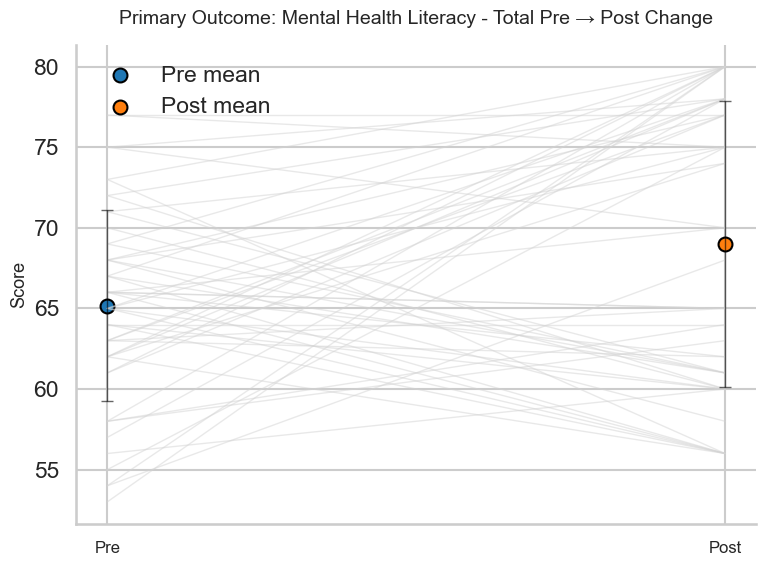

In [17]:
# ------------------------------------------------------------
# Primary outcome
# ------------------------------------------------------------

for pre, post in primary_pairs:
    plot_prepost(data, pre, post, group_name="Primary Outcome")

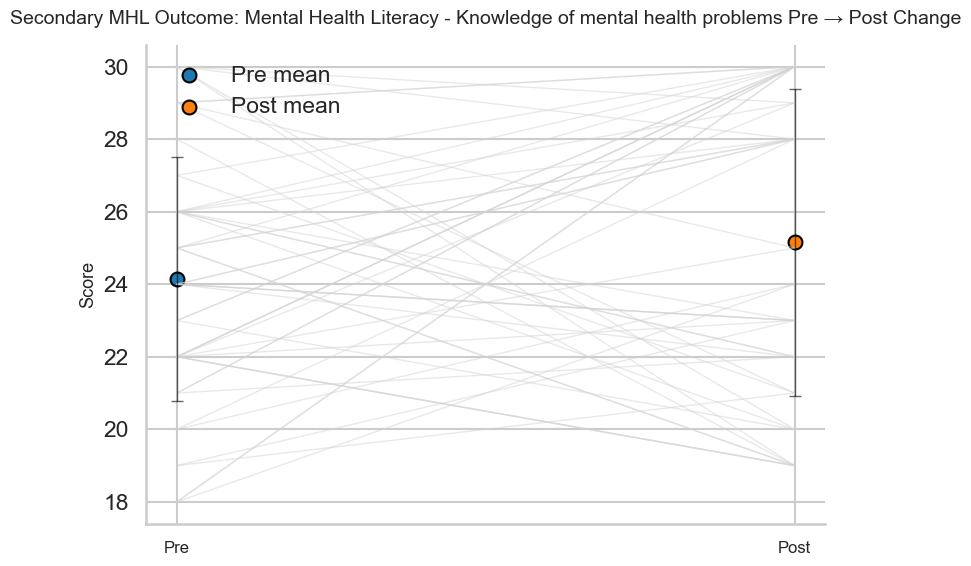

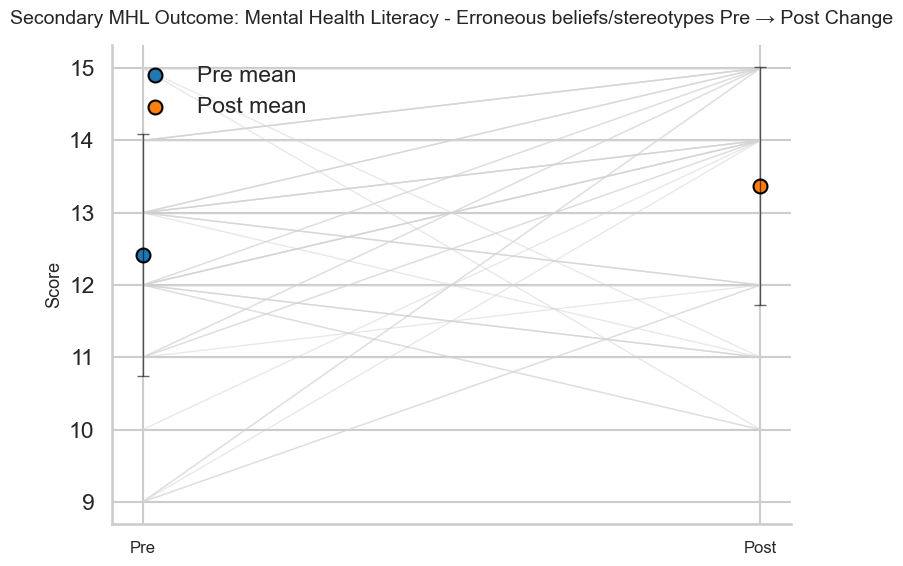

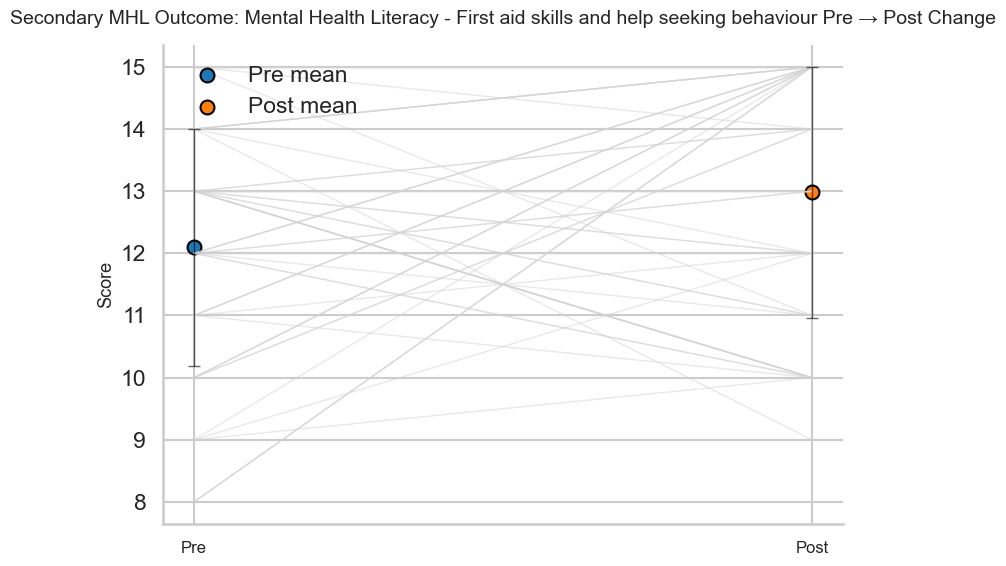

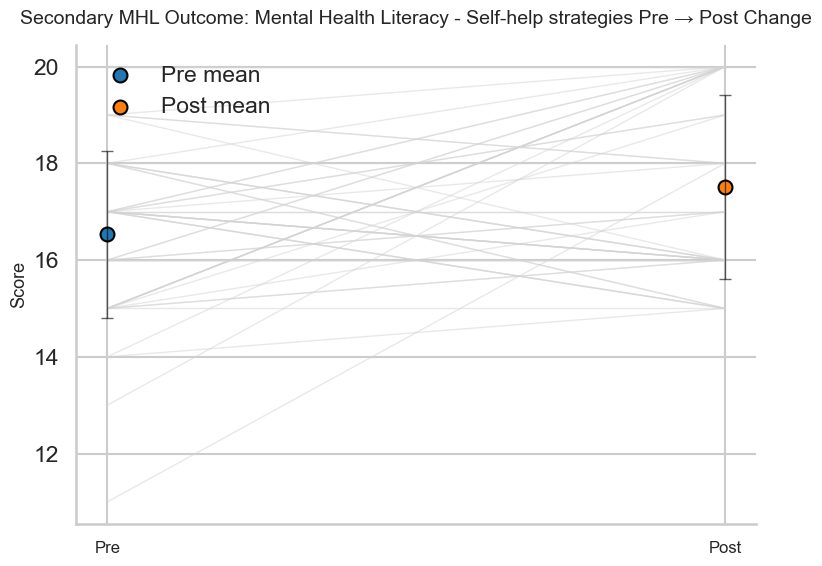

In [18]:
# ------------------------------------------------------------
# Secondary MHL outcomes
# ------------------------------------------------------------

for pre, post in secondary_mhl_pairs:
    plot_prepost(data, pre, post, group_name="Secondary MHL Outcome")

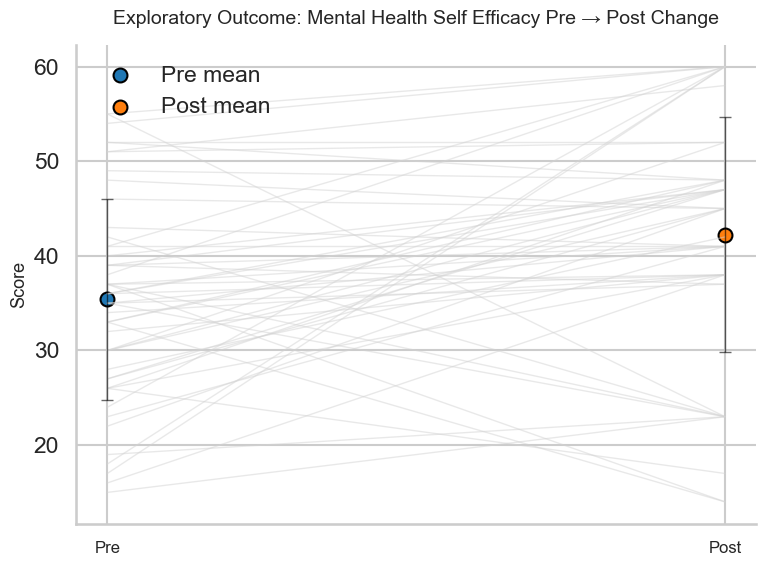

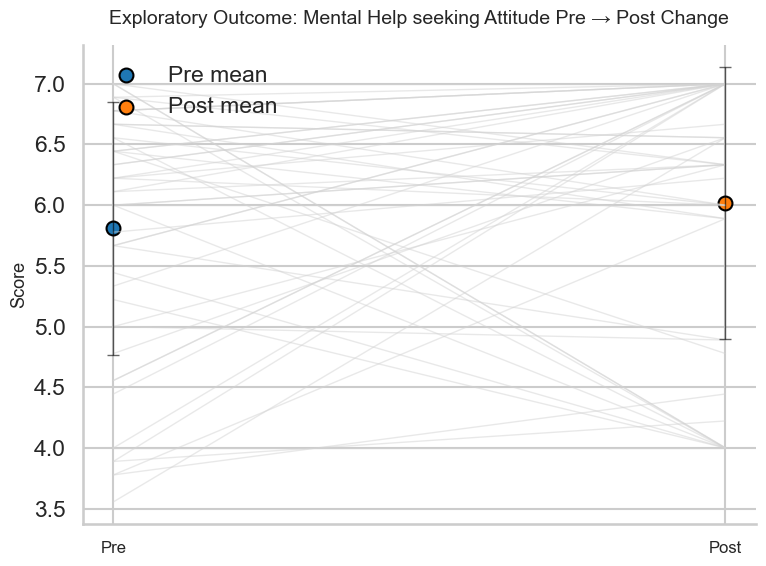

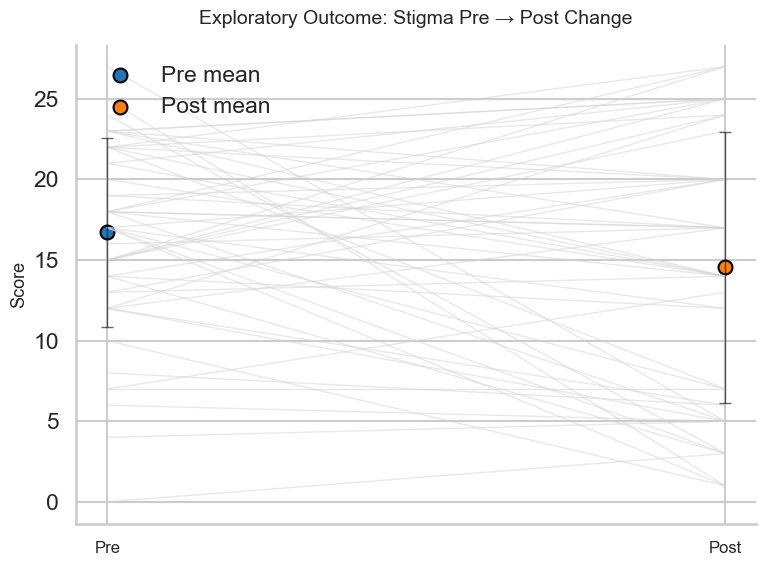

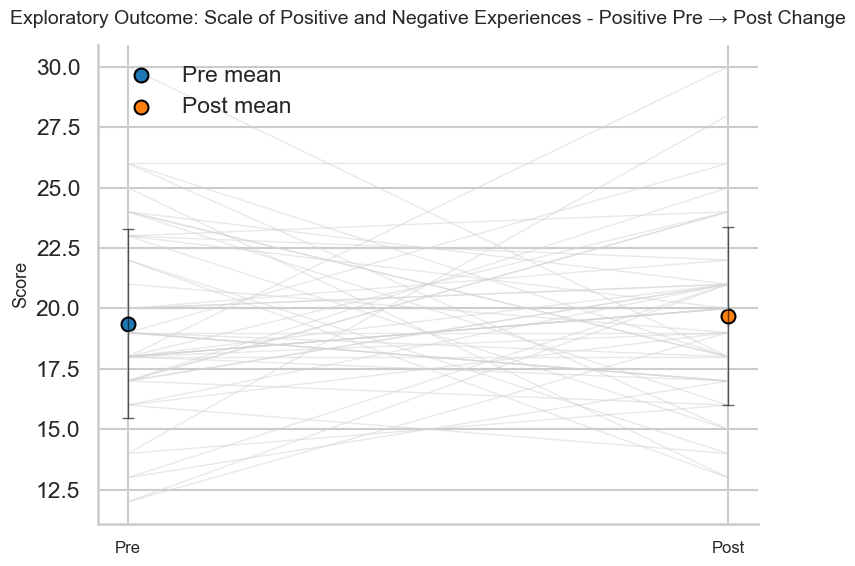

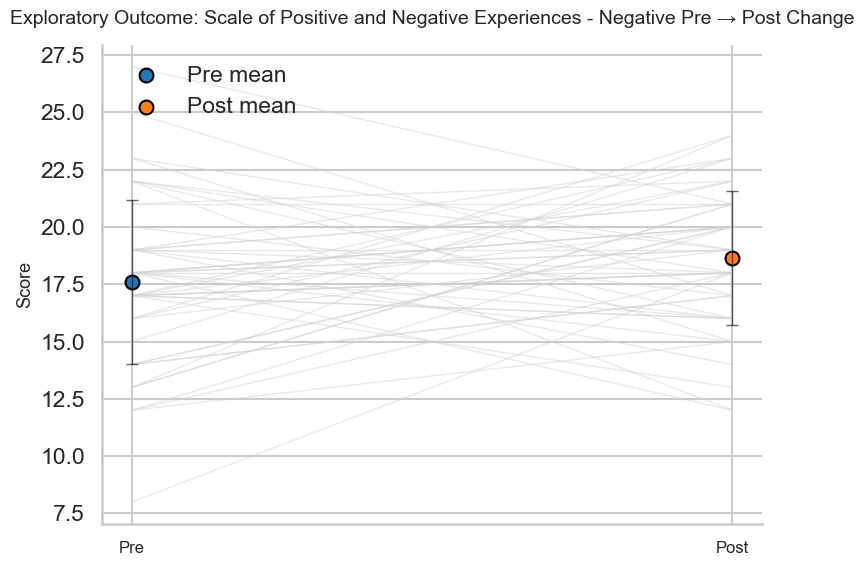

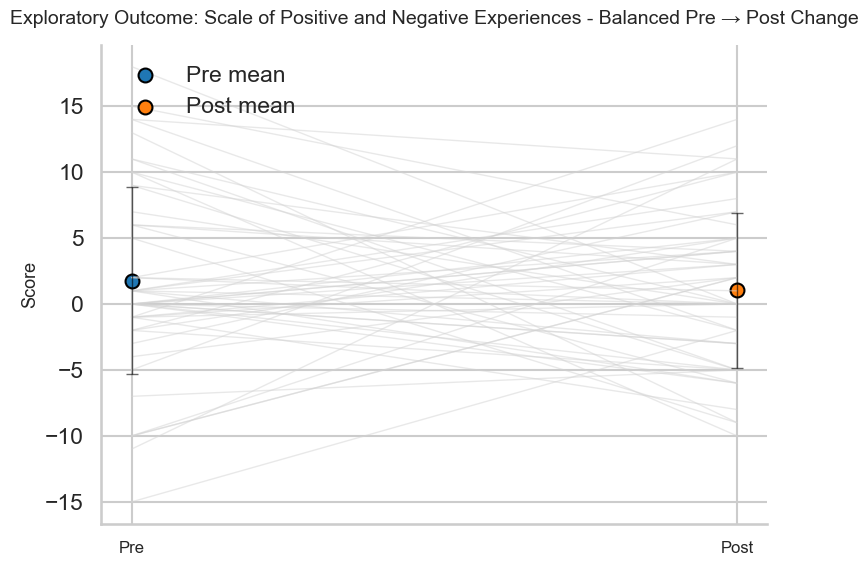

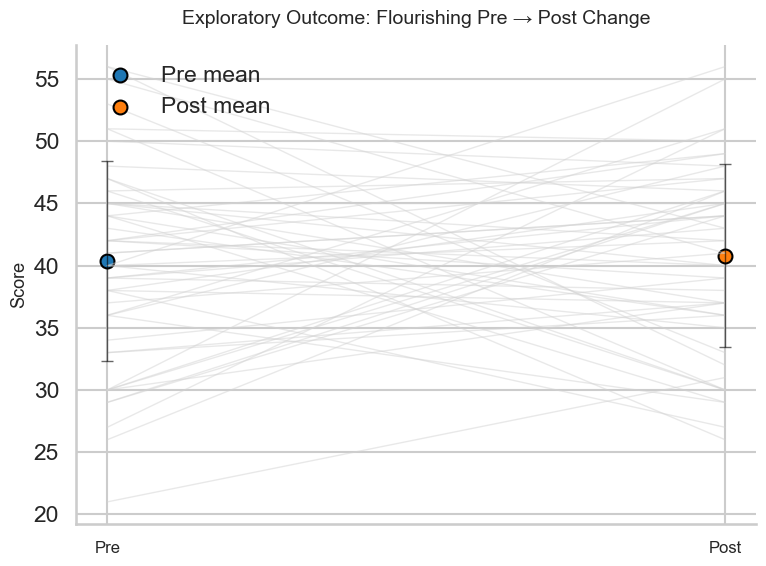

In [19]:
# ------------------------------------------------------------
# Exploratory psychological outcomes
# ------------------------------------------------------------

for pre, post in exploratory_pairs:
    plot_prepost(data, pre, post, group_name="Exploratory Outcome")

Slope plots visualize within-subject change for each outcome. Each gray line represents one participant, while colored markers indicate pre/post means with standard deviation bars. 
These visuals complement the paired t-tests by illustrating both direction and consistency of change.

The following diagnostic plots assess the paired t-test assumptions related to the distribution of paired differences: approximate normality and absence of extreme influential outliers.

In [20]:
# Paired differences for the primary outcome

mhl_diff = data["post_mhl_total"] - data["pre_mhl_total"]

mhl_diff.describe()

count    51.000000
mean      3.843137
std      11.127214
min     -17.000000
25%      -5.500000
50%       4.000000
75%      13.000000
max      27.000000
dtype: float64

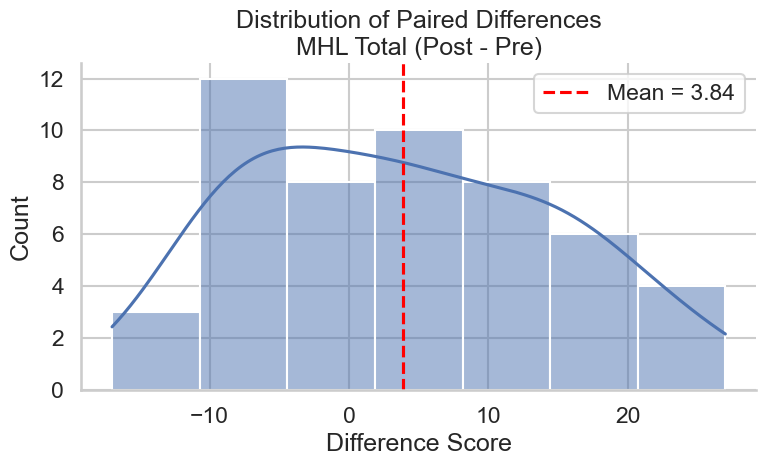

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    mhl_diff,
    bins="auto",
    kde=True
)

plt.axvline(
    mhl_diff.mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {mhl_diff.mean():.2f}"
)

plt.title("Distribution of Paired Differences\nMHL Total (Post - Pre)")
plt.xlabel("Difference Score")
plt.ylabel("Count")
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

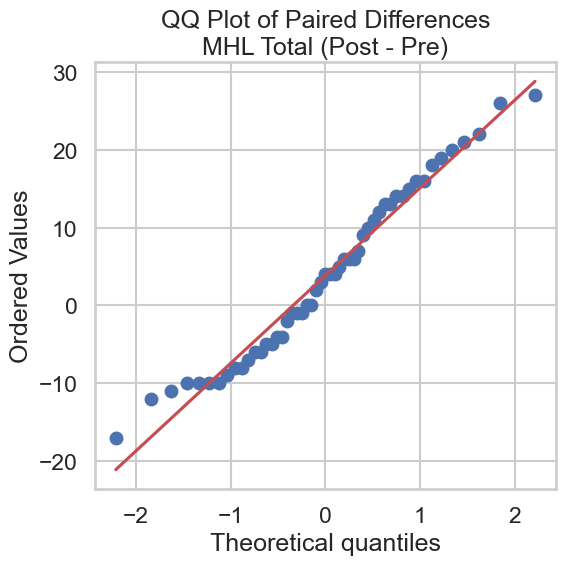

In [22]:
from scipy import stats

plt.figure(figsize=(6, 6))

stats.probplot(
    mhl_diff,
    dist="norm",
    plot=plt
)

plt.title("QQ Plot of Paired Differences\nMHL Total (Post - Pre)")

plt.tight_layout()
plt.show()

The histogram of paired differences suggests an approximately symmetric and unimodal distribution. The QQ plot shows that the observed differences closely follow the theoretical normal distribution, with only minor deviations in the tails.

No substantial departures from normality were observed. No obvious extreme influential outliers were visible in the paired differences. Therefore, the normality and outlier assumptions required for the paired t-test were considered reasonable for the primary outcome (MHL Total).

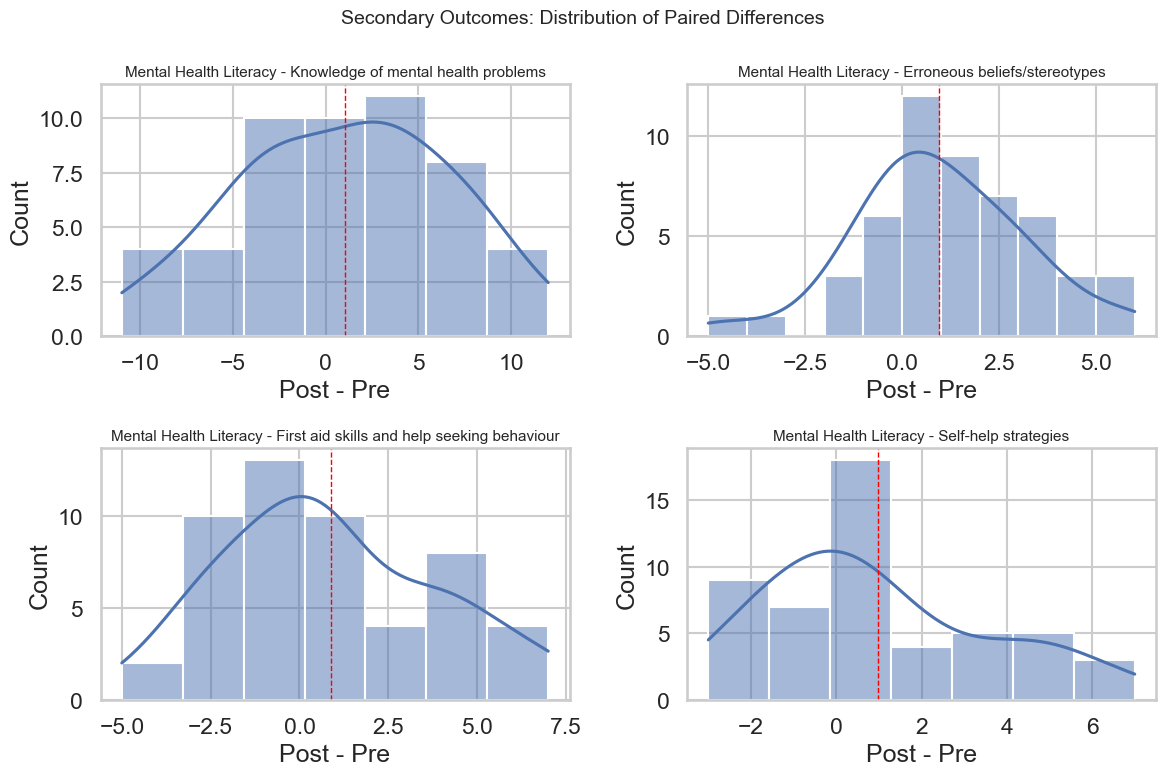

In [23]:
# ------------------------------------------------------------
# Histograms of paired differences
# Secondary Outcomes (MHL subscales)
# ------------------------------------------------------------

secondary_pairs = [
    ("pre_mhl_kmhp", "post_mhl_kmhp"),
    ("pre_mhl_ebs", "post_mhl_ebs"),
    ("pre_mhl_fashsb", "post_mhl_fashsb"),
    ("pre_mhl_shs", "post_mhl_shs"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()

for ax, (pre, post) in zip(axes, secondary_pairs):

    diff = data[post] - data[pre]

    sns.histplot(
        diff,
        bins="auto",
        kde=True,
        ax=ax
    )

    ax.axvline(
        diff.mean(),
        color="red",
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        L(pre).replace("Pre-test - ", ""),
        fontsize=11
    )

    ax.set_xlabel("Post - Pre")
    ax.set_ylabel("Count")

plt.suptitle(
    "Secondary Outcomes: Distribution of Paired Differences",
    fontsize=14
)

plt.tight_layout()
plt.show()

Visual inspection suggested that the distributions of paired differences were broadly consistent with approximate normality. No substantial outliers were observed. The Self-Help Strategies subscale displayed mild positive skewness, but not to a degree considered problematic for the planned paired t-tests

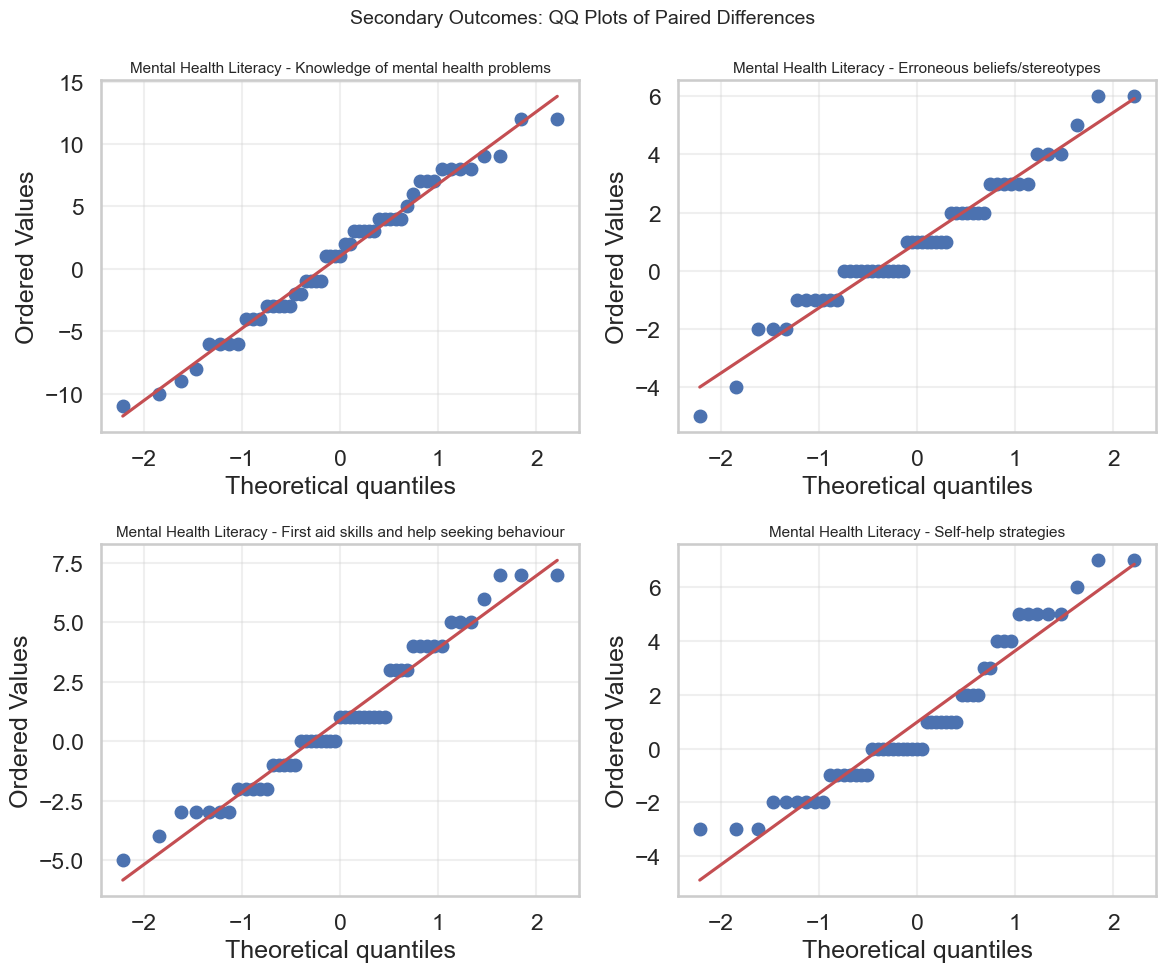

In [24]:
# ------------------------------------------------------------
# QQ plots of paired differences
# Secondary Outcomes (MHL subscales)
# ------------------------------------------------------------

from scipy import stats

secondary_pairs = [
    ("pre_mhl_kmhp", "post_mhl_kmhp"),
    ("pre_mhl_ebs", "post_mhl_ebs"),
    ("pre_mhl_fashsb", "post_mhl_fashsb"),
    ("pre_mhl_shs", "post_mhl_shs"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes = axes.flatten()

for ax, (pre, post) in zip(axes, secondary_pairs):

    diff = data[post] - data[pre]

    stats.probplot(
        diff,
        dist="norm",
        plot=ax
    )

    ax.set_title(
        L(pre).replace("Pre-test - ", ""),
        fontsize=11
    )

    ax.grid(alpha=0.3)

plt.suptitle(
    "Secondary Outcomes: QQ Plots of Paired Differences",
    fontsize=14
)

plt.tight_layout()
plt.show()

QQ plots of the paired differences indicated that all secondary outcomes were broadly consistent with approximate normality. Minor departures from the reference line were observed for the Self-Help Strategies subscale, suggesting mild positive skewness. However, no severe deviations or extreme outliers were evident, and the assumptions for the paired t-tests were considered adequately satisfied

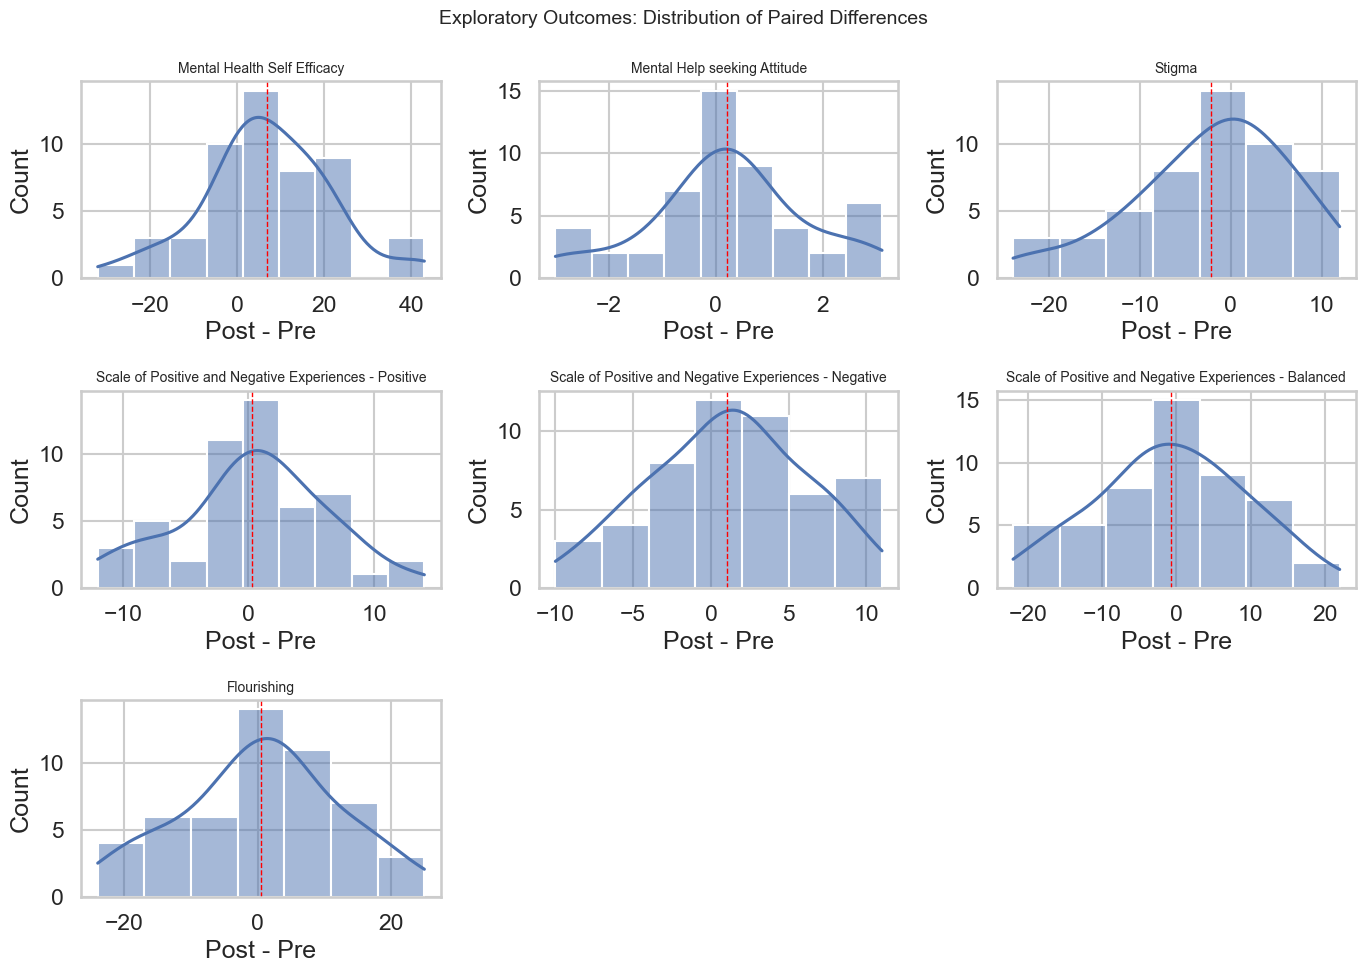

In [25]:
# ------------------------------------------------------------
# Histograms of paired differences
# Exploratory Outcomes
# ------------------------------------------------------------

exploratory_pairs = [
    ("pre_mhses", "post_mhses"),
    ("pre_mhsas", "post_mhsas"),
    ("pre_stig", "post_stig"),
    ("pre_spane_p", "post_spane_p"),
    ("pre_spane_n", "post_spane_n"),
    ("pre_spane_b", "post_spane_b"),
    ("pre_flousc", "post_flousc"),
]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))

axes = axes.flatten()

for ax, (pre, post) in zip(axes, exploratory_pairs):

    diff = data[post] - data[pre]

    sns.histplot(
        diff,
        bins="auto",
        kde=True,
        ax=ax
    )

    ax.axvline(
        diff.mean(),
        color="red",
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        L(pre).replace("Pre-test - ", ""),
        fontsize=10
    )

    ax.set_xlabel("Post - Pre")
    ax.set_ylabel("Count")

# Hide unused panels
for ax in axes[len(exploratory_pairs):]:
    ax.set_visible(False)

plt.suptitle(
    "Exploratory Outcomes: Distribution of Paired Differences",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Assumption Diagnostics: Exploratory Outcomes

Histograms of the paired differences (Post − Pre) were inspected for all exploratory outcomes. The distributions appeared broadly unimodal and approximately symmetric, with no evidence of severe skewness or extreme outliers. Overall, no substantial violations of the normality assumption were observed, and the paired t-test was considered appropriate for the exploratory analyses.

# 3- Statistical Analysis

In [26]:
# ------------------------------------------------------------
# 3.1 Imports and setup
# ------------------------------------------------------------

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Stats
import scipy.stats as st

# Project paths
from mh.paths import PROC_DIR, FIGURES_DIR

# Read data & codebook
data_path = PROC_DIR / "clean.csv"
codebook_path = PROC_DIR / "codebook_normalized.csv"

data = pd.read_csv(data_path)
codebook = pd.read_csv(codebook_path)

# Labels
labels = dict(zip(codebook["variable_new"], codebook["description"]))

def L(col: str) -> str:
    return labels.get(col, col.replace("_", " ").title())

# Output directories
TABLES_DIR = FIGURES_DIR.parent / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

In [27]:
# ------------------------------------------------------------
# 3.2 Define outcome hierarchy
# ------------------------------------------------------------

# Primary outcome: main efficacy endpoint
primary_pairs = [
    ("pre_mhl_total", "post_mhl_total"),
]

# Secondary outcomes: mental health literacy subscales
secondary_pairs = [
    ("pre_mhl_kmhp", "post_mhl_kmhp"),
    ("pre_mhl_ebs", "post_mhl_ebs"),
    ("pre_mhl_fashsb", "post_mhl_fashsb"),
    ("pre_mhl_shs", "post_mhl_shs"),
]

# Exploratory psychological outcomes
exploratory_pairs = [
    ("pre_mhses", "post_mhses"),
    ("pre_mhsas", "post_mhsas"),
    ("pre_stig", "post_stig"),
    ("pre_spane_p", "post_spane_p"),
    ("pre_spane_n", "post_spane_n"),
    ("pre_spane_b", "post_spane_b"),
    ("pre_flousc", "post_flousc"),
]

In [28]:
# ------------------------------------------------------------
# 3.3 Paired t-test helper function
# ------------------------------------------------------------

def paired_test(df, pre, post, outcome_group):
    """
    Run paired t-test for one pre/post outcome pair.

    Returns:
    - sample size
    - pre/post means
    - mean paired difference
    - 95% CI for mean difference
    - paired t-test statistic and p-value
    - Cohen's dz for paired samples
    """

    paired = df[[pre, post]].dropna().astype(float)

    pre_values = paired[pre]
    post_values = paired[post]
    diff = post_values - pre_values

    n = len(diff)

    mean_pre = pre_values.mean()
    mean_post = post_values.mean()
    mean_diff = diff.mean()

    sd_diff = diff.std(ddof=1)
    se_diff = sd_diff / np.sqrt(n)

    # Paired t-test
    t_stat, p_value = st.ttest_rel(post_values, pre_values)

    # 95% confidence interval for the mean paired difference
    t_crit = st.t.ppf(0.975, df=n - 1)
    ci_low = mean_diff - t_crit * se_diff
    ci_high = mean_diff + t_crit * se_diff

    # Cohen's dz for paired samples
    cohen_dz = mean_diff / sd_diff if sd_diff > 0 else np.nan

    # Shapiro-Wilk test for paired differences
    if n >= 3:
        shapiro_w, shapiro_p = st.shapiro(diff)
    else:
        shapiro_w, shapiro_p = np.nan, np.nan

    return {
        "outcome_group": outcome_group,
        "variable": pre.replace("pre_", ""),
        "label": L(pre).replace("Pre-test - ", ""),
        "n": n,
        "mean_pre": mean_pre,
        "mean_post": mean_post,
        "mean_diff": mean_diff,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "t": t_stat,
        "p": p_value,
        "cohen_dz": cohen_dz,
        "shapiro_w": shapiro_w,
        "shapiro_p": shapiro_p,
    }


In [29]:
# ------------------------------------------------------------
# 3.4 Run paired t-tests by outcome hierarchy
# ------------------------------------------------------------

primary_results = pd.DataFrame(
    [paired_test(data, pre, post, "Primary") for pre, post in primary_pairs]
)

secondary_results = pd.DataFrame(
    [paired_test(data, pre, post, "Secondary") for pre, post in secondary_pairs]
)

exploratory_results = pd.DataFrame(
    [paired_test(data, pre, post, "Exploratory") for pre, post in exploratory_pairs]
)

all_results = pd.concat(
    [primary_results, secondary_results, exploratory_results],
    ignore_index=True
)

all_results

,outcome_group,variable,label,n,mean_pre,mean_post,mean_diff,ci_low,ci_high,t,p,cohen_dz,shapiro_w,shapiro_p
0,Primary,mhl_total,Mental Health Literacy - Total,51,65.176471,69.019608,3.843137,0.713558,6.972717,2.466519,0.017115,0.345382,0.967788,0.178736
1,Secondary,mhl_kmhp,Mental Health Literacy - Knowledge of mental h...,51,24.137255,25.156863,1.019608,-0.577849,2.617064,1.282002,0.205755,0.179516,0.979389,0.513258
2,Secondary,mhl_ebs,Mental Health Literacy - Erroneous beliefs/ste...,51,12.411765,13.372549,0.960784,0.334500,1.587069,3.081334,0.003347,0.431473,0.968815,0.197394
3,Secondary,mhl_fashsb,Mental Health Literacy - First aid skills and ...,51,12.098039,12.980392,0.882353,0.033641,1.731065,2.088173,0.041896,0.292403,0.959305,0.077905
4,Secondary,mhl_shs,Mental Health Literacy - Self-help strategies,51,16.529412,17.509804,0.980392,0.228879,1.731906,2.620280,0.011605,0.366913,0.930292,0.005108
5,Exploratory,mhses,Mental Health Self Efficacy,51,35.392157,42.235294,6.843137,2.655042,11.031233,3.281885,0.001884,0.459556,0.973389,0.304208
6,Exploratory,mhsas,Mental Help seeking Attitude,51,5.808279,6.019608,0.211329,-0.206599,0.629257,1.015645,0.314688,0.142219,0.963919,0.122551
7,Exploratory,stig,Stigma,51,16.725490,14.549020,-2.176471,-4.599642,0.246701,-1.804070,0.077246,-0.252620,0.963695,0.119889
8,Exploratory,spane_p,Scale of Positive and Negative Experiences - P...,51,19.372549,19.686275,0.313725,-1.352565,1.980016,0.378167,0.706907,0.052954,0.976190,0.391718
9,Exploratory,spane_n,Scale of Positive and Negative Experiences - N...,51,17.607843,18.647059,1.039216,-0.355717,2.434148,1.496363,0.140845,0.209533,0.981554,0.606487


In [30]:
# ------------------------------------------------------------
# 3.5 Create publication-friendly results table
# ------------------------------------------------------------

results_pretty = all_results.copy()

results_pretty["mean_pre"] = results_pretty["mean_pre"].round(2)
results_pretty["mean_post"] = results_pretty["mean_post"].round(2)
results_pretty["mean_diff"] = results_pretty["mean_diff"].round(2)
results_pretty["t"] = results_pretty["t"].round(2)
results_pretty["p"] = results_pretty["p"].apply(lambda x: f"{x:.3f}")
results_pretty["cohen_dz"] = results_pretty["cohen_dz"].round(2)
results_pretty["ci_95"] = results_pretty.apply(
    lambda row: f"[{row.ci_low:.2f}, {row.ci_high:.2f}]",
    axis=1
)

results_pretty = results_pretty[
    [
        "outcome_group",
        "variable",
        "label",
        "n",
        "mean_pre",
        "mean_post",
        "mean_diff",
        "ci_95",
        "t",
        "p",
        "cohen_dz",
        "shapiro_p",
    ]
]

results_pretty

,outcome_group,variable,label,n,mean_pre,mean_post,mean_diff,ci_95,t,p,cohen_dz,shapiro_p
0,Primary,mhl_total,Mental Health Literacy - Total,51,65.18,69.02,3.84,"[0.71, 6.97]",2.47,0.017,0.35,0.178736
1,Secondary,mhl_kmhp,Mental Health Literacy - Knowledge of mental h...,51,24.14,25.16,1.02,"[-0.58, 2.62]",1.28,0.206,0.18,0.513258
2,Secondary,mhl_ebs,Mental Health Literacy - Erroneous beliefs/ste...,51,12.41,13.37,0.96,"[0.33, 1.59]",3.08,0.003,0.43,0.197394
3,Secondary,mhl_fashsb,Mental Health Literacy - First aid skills and ...,51,12.10,12.98,0.88,"[0.03, 1.73]",2.09,0.042,0.29,0.077905
4,Secondary,mhl_shs,Mental Health Literacy - Self-help strategies,51,16.53,17.51,0.98,"[0.23, 1.73]",2.62,0.012,0.37,0.005108
5,Exploratory,mhses,Mental Health Self Efficacy,51,35.39,42.24,6.84,"[2.66, 11.03]",3.28,0.002,0.46,0.304208
6,Exploratory,mhsas,Mental Help seeking Attitude,51,5.81,6.02,0.21,"[-0.21, 0.63]",1.02,0.315,0.14,0.122551
7,Exploratory,stig,Stigma,51,16.73,14.55,-2.18,"[-4.60, 0.25]",-1.80,0.077,-0.25,0.119889
8,Exploratory,spane_p,Scale of Positive and Negative Experiences - P...,51,19.37,19.69,0.31,"[-1.35, 1.98]",0.38,0.707,0.05,0.391718
9,Exploratory,spane_n,Scale of Positive and Negative Experiences - N...,51,17.61,18.65,1.04,"[-0.36, 2.43]",1.50,0.141,0.21,0.606487


In [31]:
# ------------------------------------------------------------
# 3.6 Save results tables
# ------------------------------------------------------------

all_results.to_csv(TABLES_DIR / "paired_tests_full.csv", index=False)
results_pretty.to_csv(TABLES_DIR / "paired_tests_pretty.csv", index=False)

Interpretation

In [32]:
results_pretty.query("outcome_group == 'Primary'")

,outcome_group,variable,label,n,mean_pre,mean_post,mean_diff,ci_95,t,p,cohen_dz,shapiro_p
0,Primary,mhl_total,Mental Health Literacy - Total,51,65.18,69.02,3.84,"[0.71, 6.97]",2.47,0.017,0.35,0.178736


The paired t-test indicated a statistically significant increase in mental health literacy from pre-test (M = 65.18) to post-test (M = 69.02). Participants improved by an average of 3.84 points (95% CI [0.71, 6.97]), t(50) = 2.47, p = .017.

The effect size was small-to-moderate (Cohen's dz = 0.35), suggesting a modest but meaningful increase in mental health literacy following the intervention. The Shapiro-Wilk test did not indicate substantial departure from normality (p = .178), supporting the visual diagnostics.

In [33]:
results_pretty.query("outcome_group == 'Secondary'")

,outcome_group,variable,label,n,mean_pre,mean_post,mean_diff,ci_95,t,p,cohen_dz,shapiro_p
1,Secondary,mhl_kmhp,Mental Health Literacy - Knowledge of mental h...,51,24.14,25.16,1.02,"[-0.58, 2.62]",1.28,0.206,0.18,0.513258
2,Secondary,mhl_ebs,Mental Health Literacy - Erroneous beliefs/ste...,51,12.41,13.37,0.96,"[0.33, 1.59]",3.08,0.003,0.43,0.197394
3,Secondary,mhl_fashsb,Mental Health Literacy - First aid skills and ...,51,12.10,12.98,0.88,"[0.03, 1.73]",2.09,0.042,0.29,0.077905
4,Secondary,mhl_shs,Mental Health Literacy - Self-help strategies,51,16.53,17.51,0.98,"[0.23, 1.73]",2.62,0.012,0.37,0.005108


Analysis of the mental health literacy subscales revealed a mixed pattern of results. Significant improvements were observed for Erroneous Beliefs and Stereotypes (p = .003), 
First Aid and Help-Seeking Behaviour (p = .042), and Self-Help Strategies (p = .012). Effect sizes ranged from small to moderate (dz = 0.29–0.43).
In contrast, Knowledge of Mental Health Problems did not show a statistically significant improvement (p = .206). The corresponding confidence interval included zero, 
indicating that the observed increase of approximately one point could plausibly be attributable to sampling variability.
Overall, the intervention appears to have influenced beliefs, coping strategies, and help-seeking knowledge more strongly than factual knowledge of mental health conditions

In [34]:
results_pretty.query("outcome_group == 'Exploratory'")

,outcome_group,variable,label,n,mean_pre,mean_post,mean_diff,ci_95,t,p,cohen_dz,shapiro_p
5,Exploratory,mhses,Mental Health Self Efficacy,51,35.39,42.24,6.84,"[2.66, 11.03]",3.28,0.002,0.46,0.304208
6,Exploratory,mhsas,Mental Help seeking Attitude,51,5.81,6.02,0.21,"[-0.21, 0.63]",1.02,0.315,0.14,0.122551
7,Exploratory,stig,Stigma,51,16.73,14.55,-2.18,"[-4.60, 0.25]",-1.80,0.077,-0.25,0.119889
8,Exploratory,spane_p,Scale of Positive and Negative Experiences - P...,51,19.37,19.69,0.31,"[-1.35, 1.98]",0.38,0.707,0.05,0.391718
9,Exploratory,spane_n,Scale of Positive and Negative Experiences - N...,51,17.61,18.65,1.04,"[-0.36, 2.43]",1.50,0.141,0.21,0.606487
10,Exploratory,spane_b,Scale of Positive and Negative Experiences - B...,51,1.76,1.04,-0.73,"[-3.58, 2.13]",-0.51,0.612,-0.07,0.923718
11,Exploratory,flousc,Flourishing,51,40.37,40.80,0.43,"[-2.90, 3.77]",0.26,0.796,0.04,0.550951


The exploratory analyses produced a mixed pattern of results. Among the exploratory outcomes, Mental Health Self-Efficacy showed a statistically significant improvement from 
pre-test to post-test, t(50) = 3.28, p = .002, with a moderate effect size (dz = 0.46). 
Participants increased their self-efficacy scores by an average of 6.84 points (95% CI [2.66, 11.03]).
In contrast, no statistically significant changes were observed for Help-Seeking Attitudes, Positive Affect, Negative Affect, Affect Balance, or Flourishing. 
Effect sizes for these outcomes were generally small and confidence intervals included zero.
Stigma scores decreased in the expected direction, suggesting reduced stigmatizing attitudes following the intervention; 
however, this effect did not reach conventional statistical significance (p = .077).
Overall, the exploratory findings suggest that the intervention may have strengthened participants' confidence in managing mental health-related situations, 
while having limited impact on broader emotional well-being or flourishing.

The strongest non-primary result is actually MHSES (Self-Efficacy). Combined with the significant improvement in MHL Total, this suggests that the intervention may have 
improved both participants' mental health knowledge and their confidence in applying that knowledge. 

Together, the significant improvement in MHL Total and Mental Health Self-Efficacy suggests that the intervention may have improved both participants' mental health knowledge and their confidence in applying that knowledge.

Acceptability outcomes: How did participants evaluate the intervention?

In [35]:
# Confirming uniform spellings 

for var in [
    "gpt_rating",
    "prompts_rating",
    "intervention_rating",
    "mhl_rating",
    "gpt_mhl",
    "gpt_flaw"
]:
    print(var)
    print(data[var].value_counts(dropna=False))
    print()

gpt_rating
gpt_rating
Excellent    27
Good         24
Name: count, dtype: int64

prompts_rating
prompts_rating
Good         30
Excellent    15
Fair          6
Name: count, dtype: int64

intervention_rating
intervention_rating
Good         26
Excellent    24
Fair          1
Name: count, dtype: int64

mhl_rating
mhl_rating
Yes      43
Maybe     8
Name: count, dtype: int64

gpt_mhl
gpt_mhl
Yes      37
Maybe    13
No        1
Name: count, dtype: int64

gpt_flaw
gpt_flaw
No       43
Maybe     8
Name: count, dtype: int64



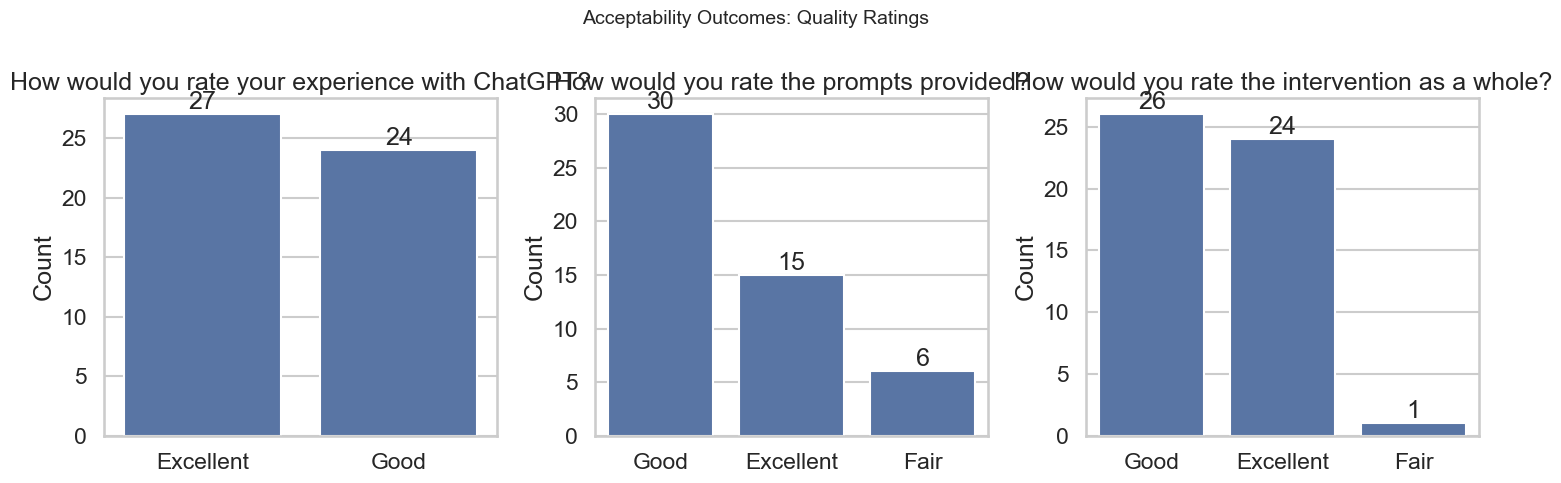

In [36]:
# Ratings

# ------------------------------------------------------------
# Acceptability outcomes:
# Quality ratings
# ------------------------------------------------------------

rating_vars = [
    "gpt_rating",
    "prompts_rating",
    "intervention_rating"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var in zip(axes, rating_vars):

    counts = data[var].value_counts(dropna=False)

    sns.barplot(
        x=counts.index,
        y=counts.values,
        ax=ax
    )

    ax.set_title(L(var))
    ax.set_xlabel("")
    ax.set_ylabel("Count")

    for container in ax.containers:
        ax.bar_label(container)

plt.suptitle(
    "Acceptability Outcomes: Quality Ratings",
    fontsize=14
)

plt.tight_layout()
plt.show()

Interpretation:
Participants evaluated the intervention very positively. Ratings of both the overall ChatGPT experience and the intervention as a whole were overwhelmingly positive, 
with nearly all responses falling into the “Good” or “Excellent” categories. The prompts were also generally well received, although interpretation of this item is limited 
because the exact prompting procedure used during the intervention is not fully documented.

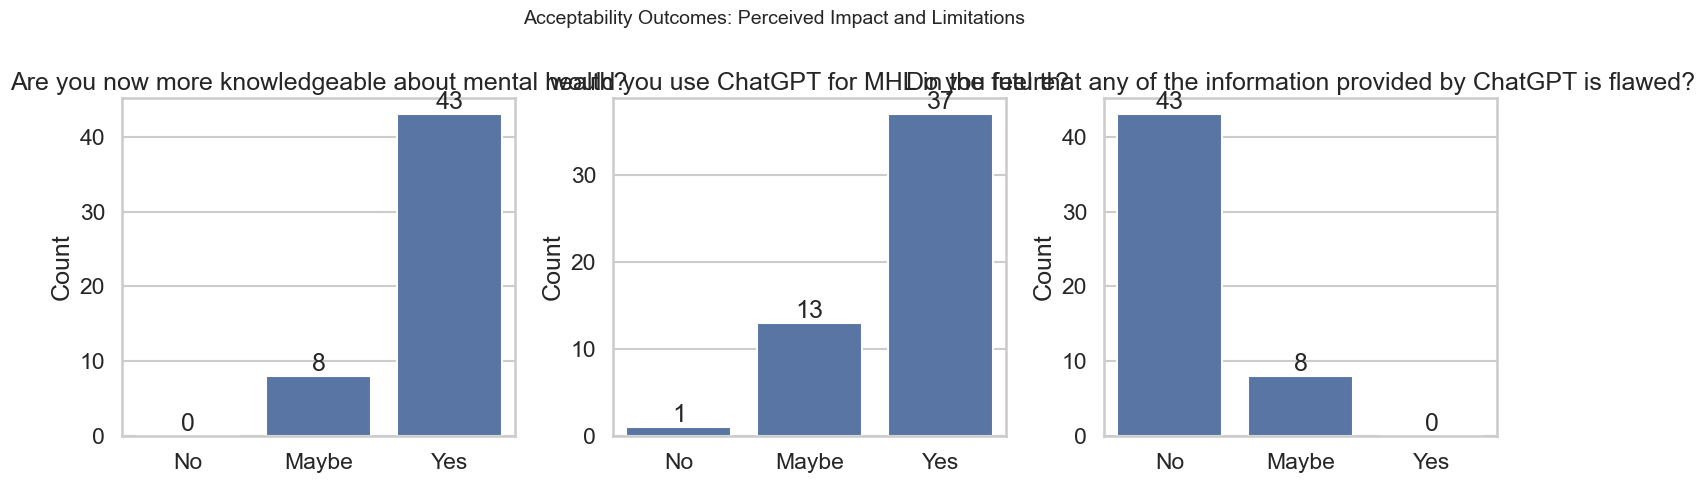

In [37]:
# Perceived impact 
# ------------------------------------------------------------
# Acceptability outcomes:
# Perceived impact and limitations
# ------------------------------------------------------------

impact_vars = [
    "mhl_rating",
    "gpt_mhl",
    "gpt_flaw"
]

response_order = ["No", "Maybe", "Yes"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var in zip(axes, impact_vars):

    counts = (
        data[var]
        .value_counts()
        .reindex(response_order, fill_value=0)
    )

    sns.barplot(
        x=counts.index,
        y=counts.values,
        ax=ax
    )

    ax.set_title(L(var))
    ax.set_xlabel("")
    ax.set_ylabel("Count")

    for container in ax.containers:
        ax.bar_label(container)

plt.suptitle(
    "Acceptability Outcomes: Perceived Impact and Limitations",
    fontsize=14
)

plt.tight_layout()
plt.show()

Participants generally perceived the intervention as beneficial. Most respondents reported feeling more knowledgeable about mental health after the intervention, 
which is consistent with the observed improvement in Mental Health Literacy scores. 
Most participants also indicated that they would consider using ChatGPT for mental health literacy purposes in the future. 
Concerns regarding flawed information were uncommon, suggesting a generally high level of trust in the information provided.